# Clustering
This notebook allows us to project embeddings into a lower dimensional space and then cluster them. Based on our earlier result, we know that around 9 dimensions in sufficient to retrain descrimination between different classes. We will use PCA, is the fastest and has been shown to be consistently the best.

We are going to try clustering with:
- KMeans
- DBScan
- Spectral Clustering

In [ ]:
from hproj.util.seeds import set_seeds


set_seeds()

In [1]:
from hproj.data.paths import Paths
from hproj.projectors.pca import PCAProjector


encoders = [
    'uni',
    'uni2',
    'hibou',
    'dinov2'
]

datasets = [
    'kather100k',
    'spider-colorectal',
    'spider-breast',
    'spider-skin',
    'spider-thorax'
]

n_components = 9

paths = Paths.from_env()

data = {}

for encoder in encoders:
    for dataset in datasets:
        # load the embeddings and labels
        embeddings_path = paths.embedding(dataset, encoder)
        train, test = embeddings_path.load_splits()

        # compute the PCA projection
        projector = PCAProjector(n_components=n_components, seed=42)
        projector.fit(train)
        train_proj = projector.transform(train)
        test_proj = projector.transform(test)

        # store the projected data
        data[(encoder, dataset)] = {'train': train_proj, 'test': test_proj}

# KMeans
The method for kmeans is:
Using the training set:
- scale the features (kmeans assumes roughly spherical clusters) - fit the scalar on the training set
- search over several values of k (we know there are between 9 and 24 classes so k = 2..32 seems smart)
- plot the elbow curve and silhoette scores and use this to select a best k
- take the clusterer that was fit to the training set with k and use it to predict cluster labels on test set
- on the test set measure silhoette, adjusted_rand_score, and adjusted_mutual_info_score

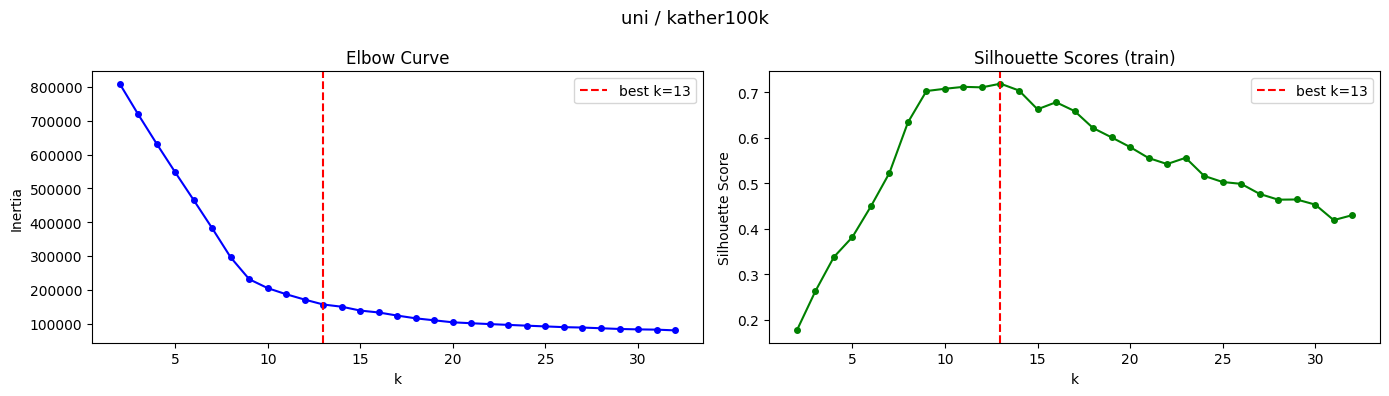

uni      / kather100k                | k=13 | sil=0.6411 | ari=0.8339 | ami=0.8640


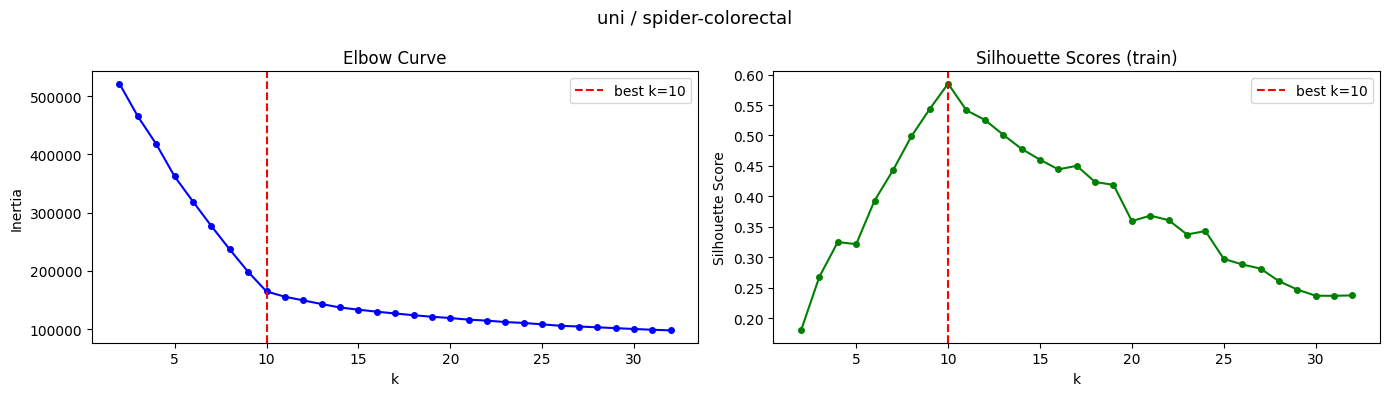

uni      / spider-colorectal         | k=10 | sil=0.6020 | ari=0.6343 | ami=0.7677


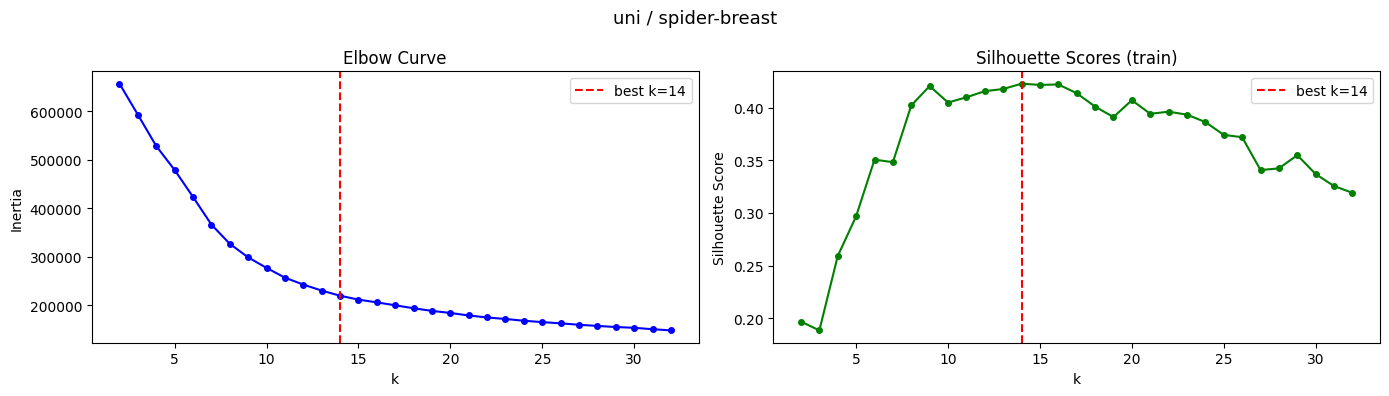

uni      / spider-breast             | k=14 | sil=0.3738 | ari=0.4885 | ami=0.6345


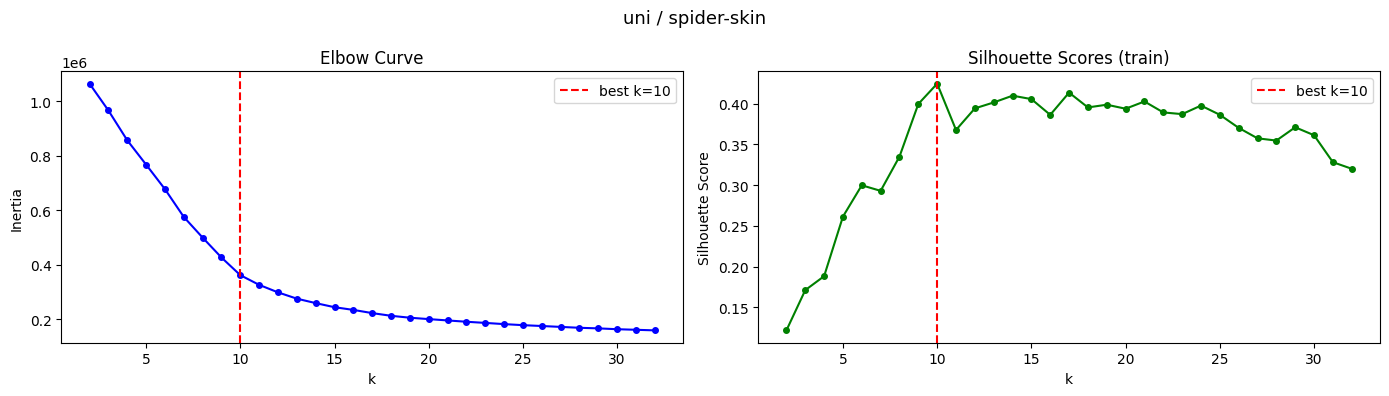

uni      / spider-skin               | k=10 | sil=0.3428 | ari=0.2664 | ami=0.5664


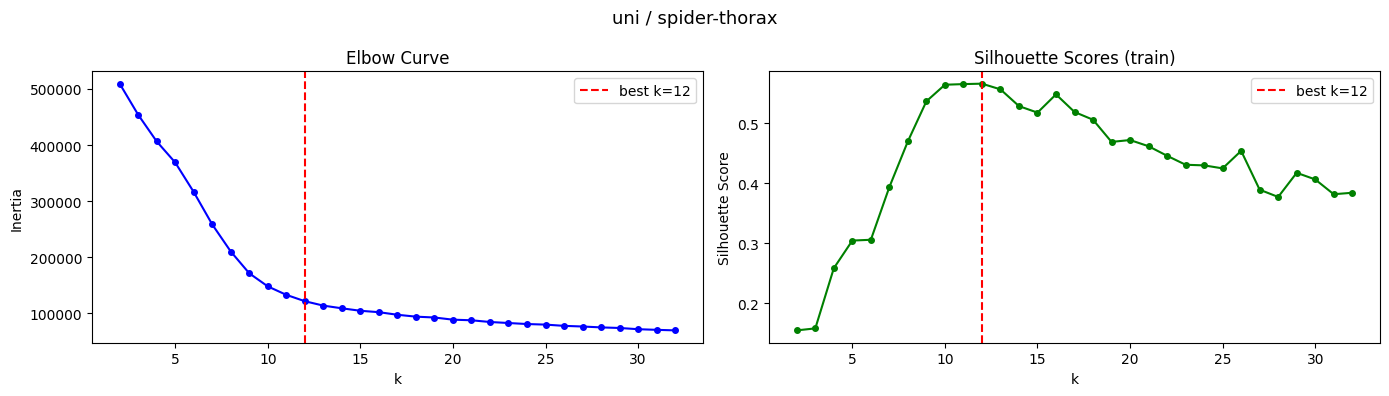

uni      / spider-thorax             | k=12 | sil=0.5154 | ari=0.6002 | ami=0.7344


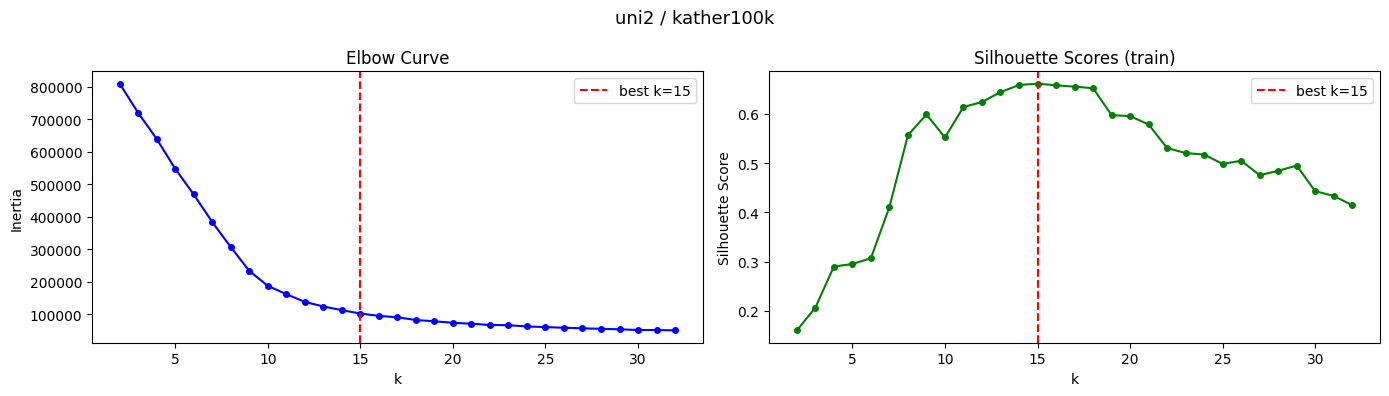

uni2     / kather100k                | k=15 | sil=0.4374 | ari=0.7072 | ami=0.7798


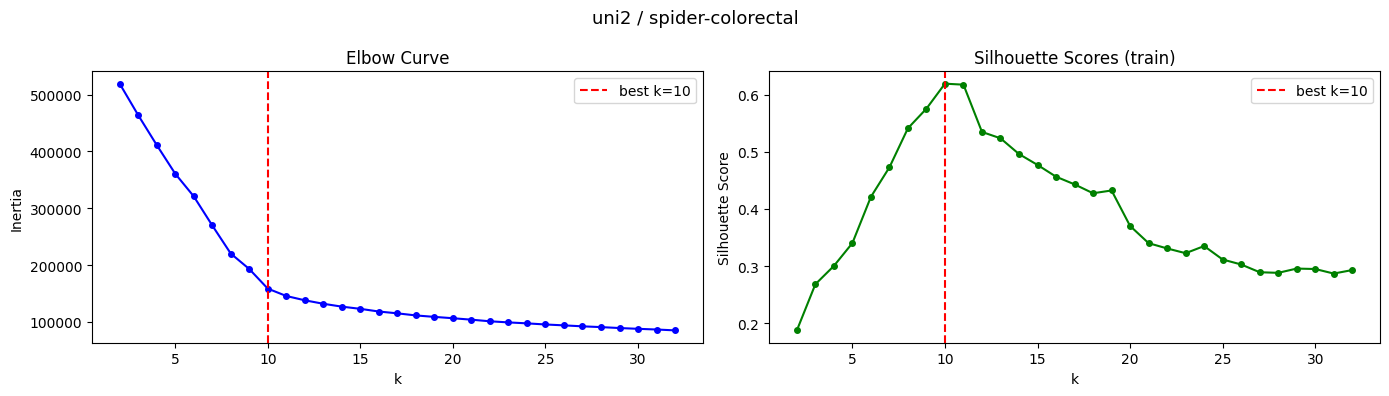

uni2     / spider-colorectal         | k=10 | sil=0.6156 | ari=0.6034 | ami=0.7424


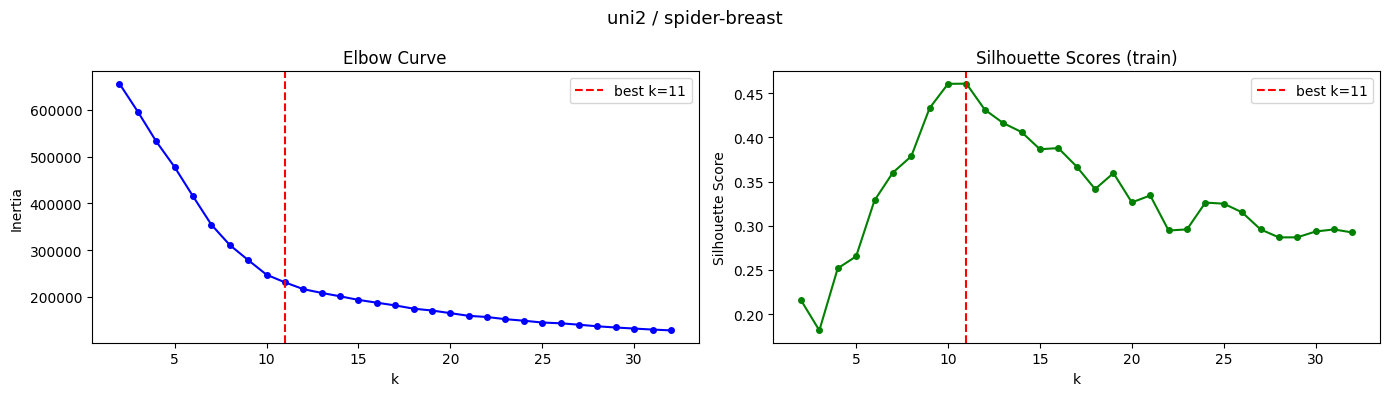

uni2     / spider-breast             | k=11 | sil=0.4292 | ari=0.4485 | ami=0.6312


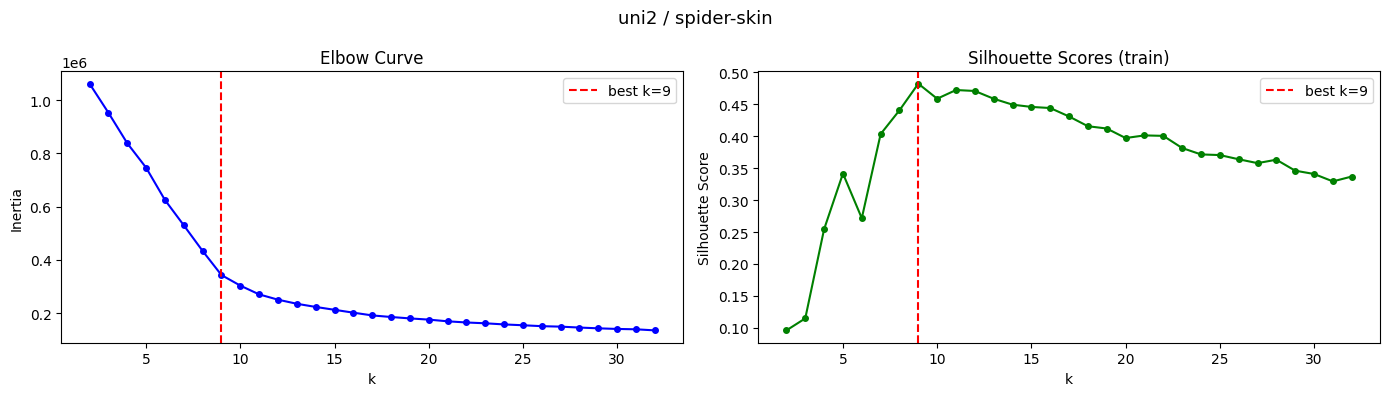

uni2     / spider-skin               | k= 9 | sil=0.3803 | ari=0.2262 | ami=0.5735


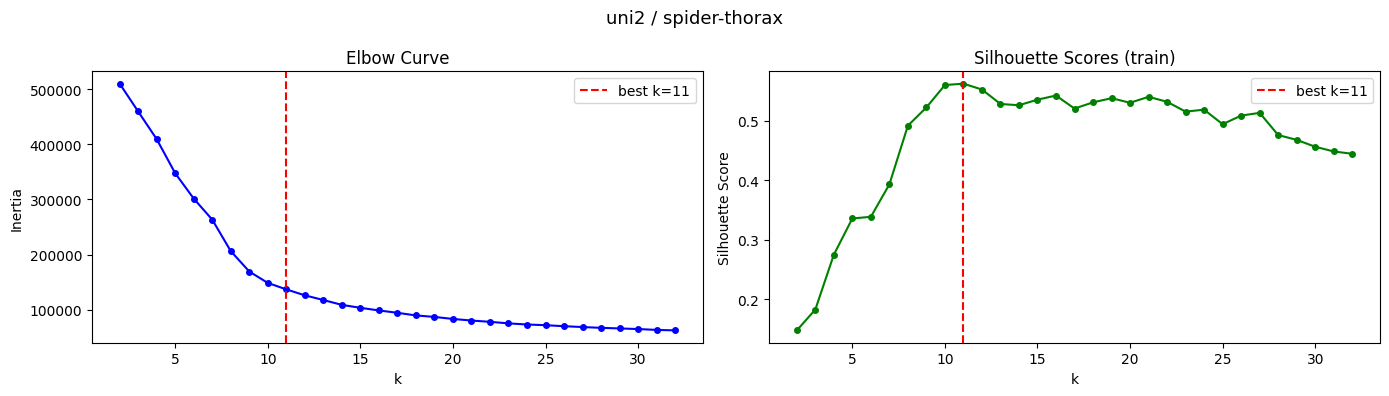

uni2     / spider-thorax             | k=11 | sil=0.5297 | ari=0.5531 | ami=0.6963


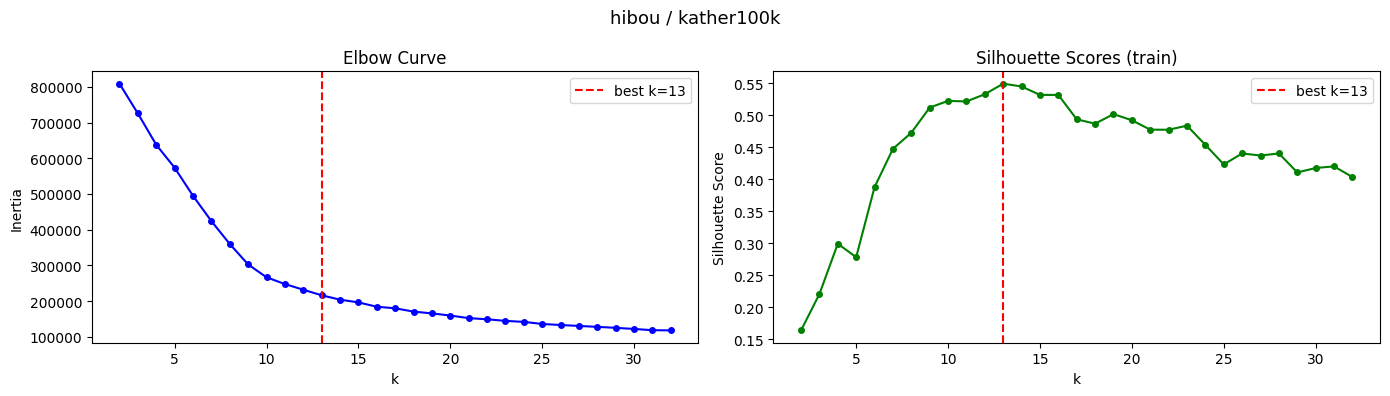

hibou    / kather100k                | k=13 | sil=0.2233 | ari=0.2282 | ami=0.4917


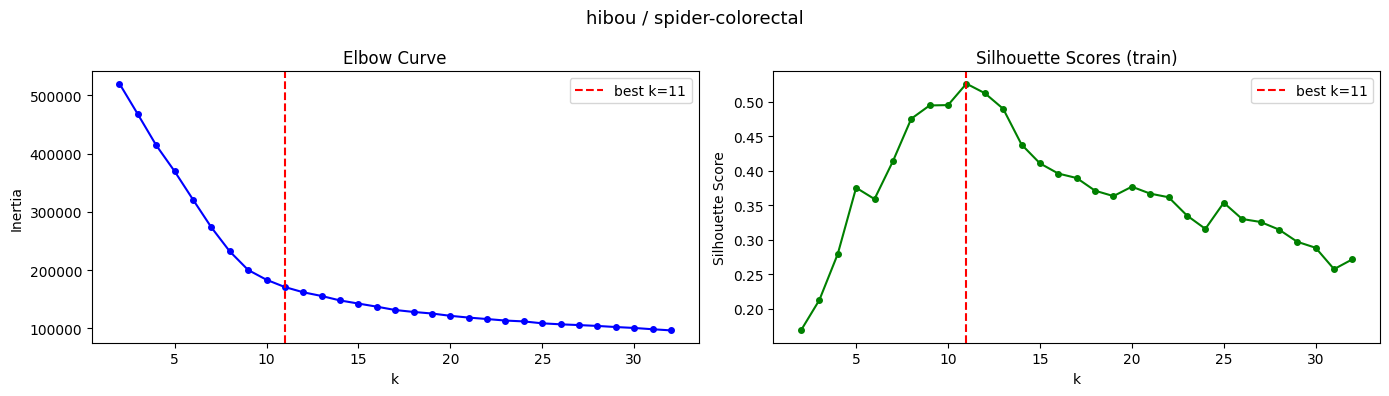

hibou    / spider-colorectal         | k=11 | sil=0.5014 | ari=0.4784 | ami=0.6765


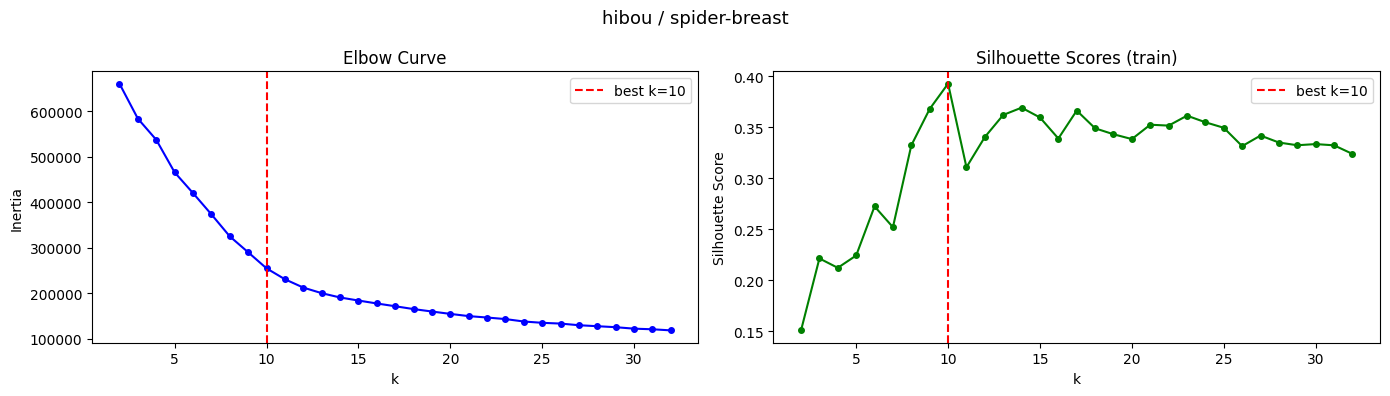

hibou    / spider-breast             | k=10 | sil=0.2804 | ari=0.2327 | ami=0.4570


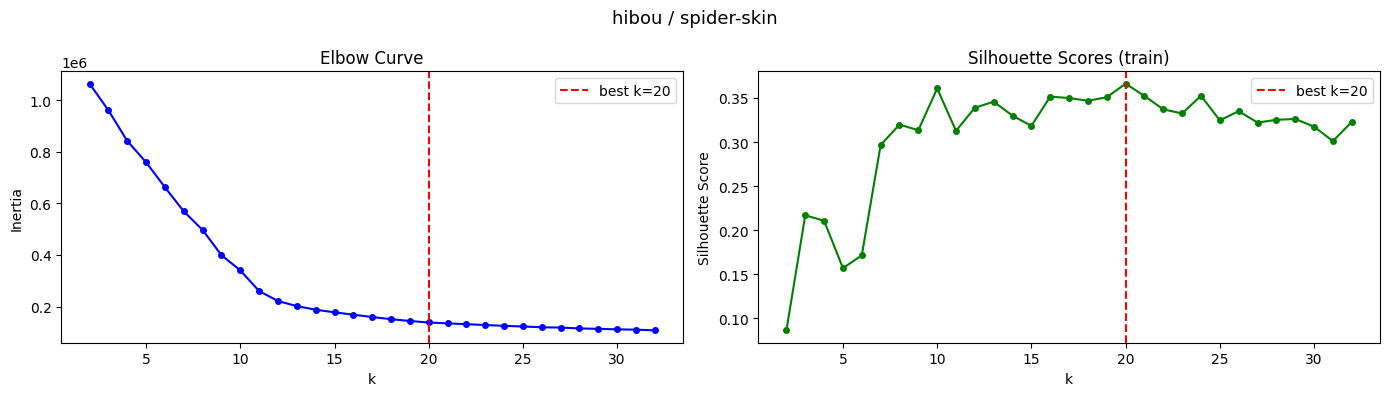

hibou    / spider-skin               | k=20 | sil=0.2485 | ari=0.4210 | ami=0.6887


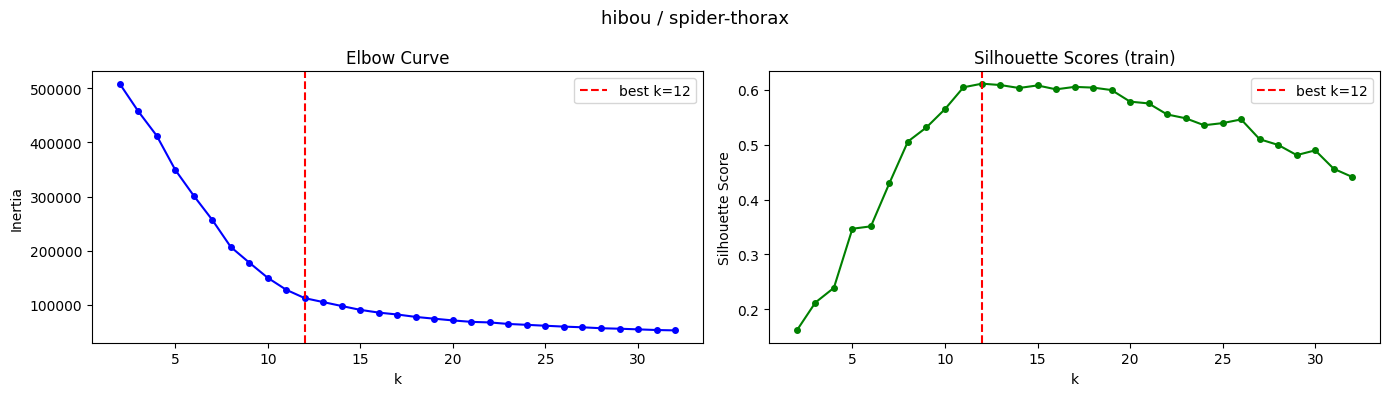

hibou    / spider-thorax             | k=12 | sil=0.5502 | ari=0.5552 | ami=0.7126


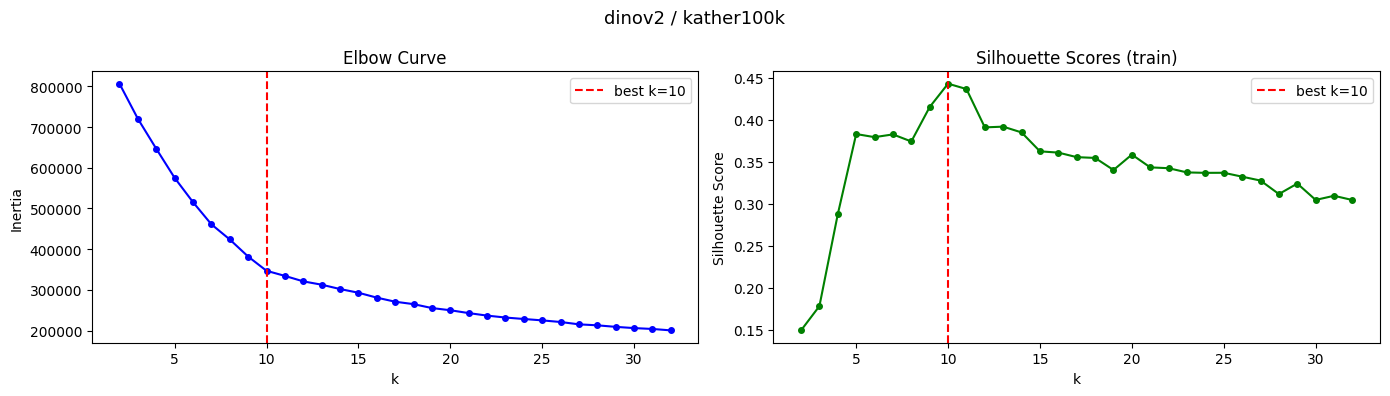

dinov2   / kather100k                | k=10 | sil=0.4176 | ari=0.4598 | ami=0.6199


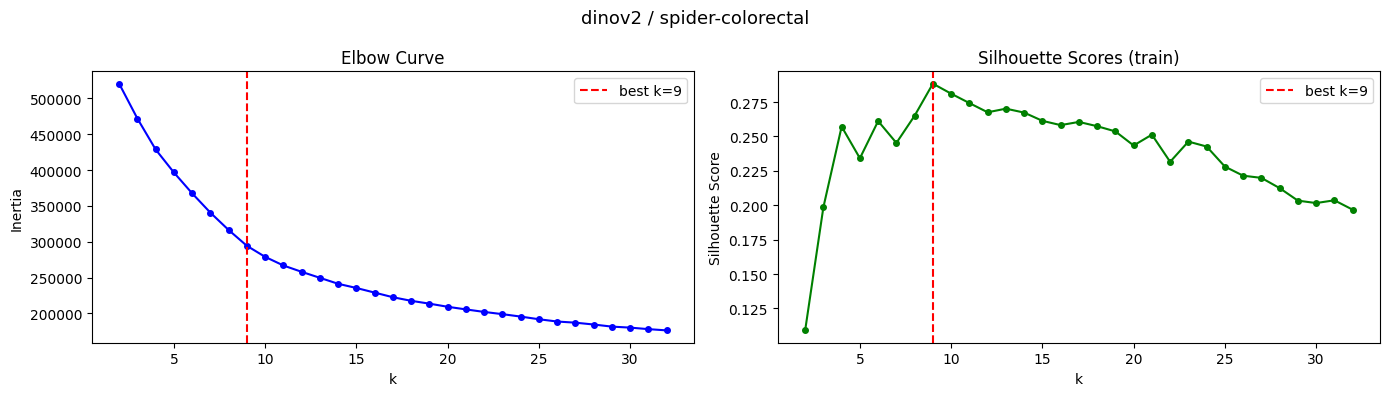

dinov2   / spider-colorectal         | k= 9 | sil=0.2918 | ari=0.2254 | ami=0.4281


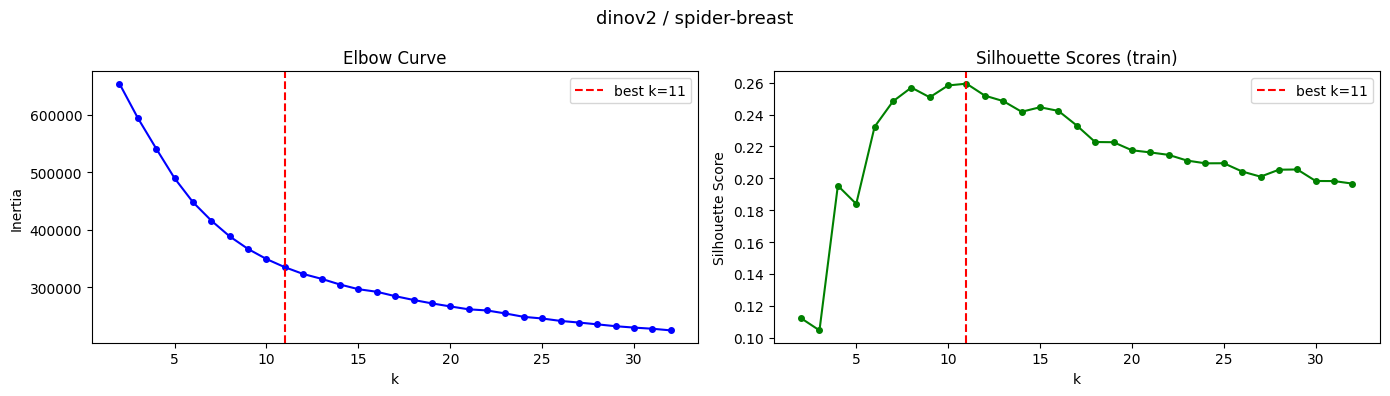

dinov2   / spider-breast             | k=11 | sil=0.2373 | ari=0.1430 | ami=0.3276


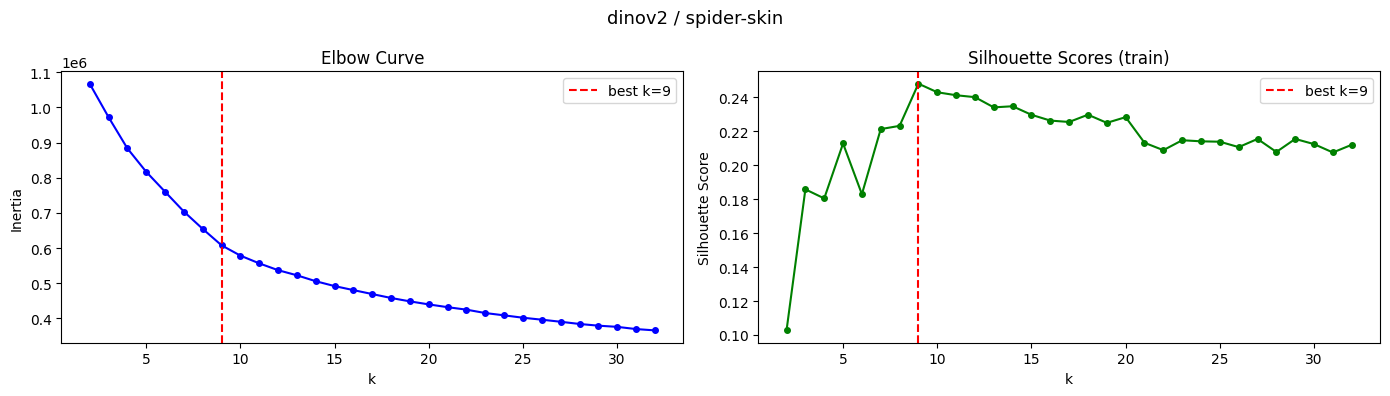

dinov2   / spider-skin               | k= 9 | sil=0.2256 | ari=0.1372 | ami=0.3619


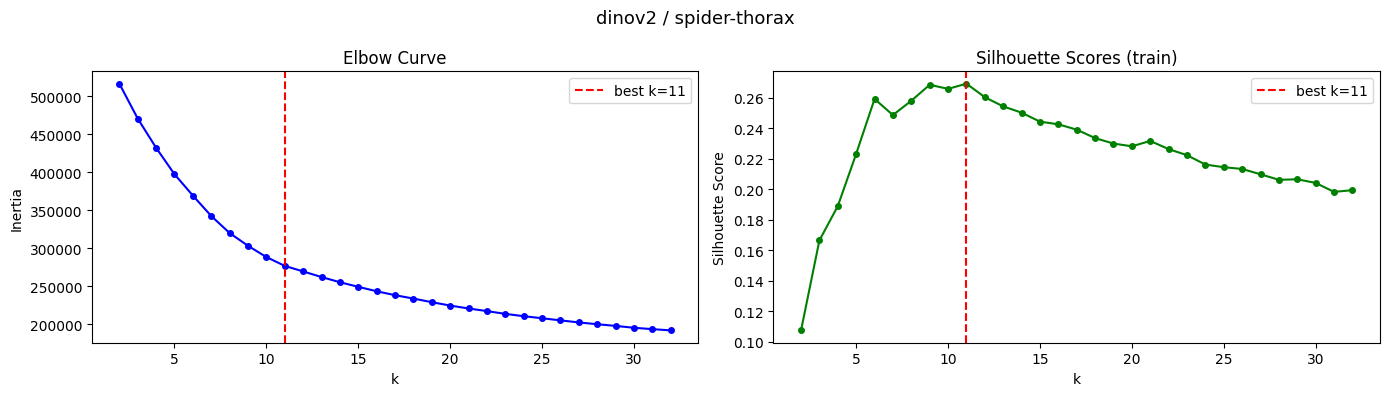

dinov2   / spider-thorax             | k=11 | sil=0.2592 | ari=0.2554 | ami=0.3756


In [2]:

import numpy as np
import matplotlib.pyplot as plt
from cuml.cluster import KMeans
from cuml.preprocessing import StandardScaler
from cuml.metrics.cluster import silhouette_score
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

k_values = list(range(2, 33))
kmeans_results = {}

for (encoder, dataset), split in data.items():
    X_train = split['train'].features
    X_test  = split['test'].features
    y_train = split['train'].labels
    y_test  = split['test'].labels

    # --- Scale features (KMeans assumes spherical clusters) ---
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled  = scaler.transform(X_test)

    # --- Search over k on the training set ---
    inertias  = []
    sil_train = []

    for k in k_values:
        km     = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X_train_scaled)
        inertias.append(float(km.inertia_))
        sil_train.append(float(silhouette_score(X_train_scaled, labels, metric='cosine')))

    sil_arr = np.array(sil_train)
    best_k  = k_values[int(np.argmax(sil_arr))]

    # --- Plot elbow curve and silhouette scores ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f'{encoder} / {dataset}', fontsize=13)

    ax1.plot(k_values, inertias, 'b-o', ms=4)
    ax1.axvline(best_k, color='r', linestyle='--', label=f'best k={best_k}')
    ax1.set_xlabel('k')
    ax1.set_ylabel('Inertia')
    ax1.set_title('Elbow Curve')
    ax1.legend()

    ax2.plot(k_values, sil_arr, 'g-o', ms=4)
    ax2.axvline(best_k, color='r', linestyle='--', label=f'best k={best_k}')
    ax2.set_xlabel('k')
    ax2.set_ylabel('Silhouette Score')
    ax2.set_title('Silhouette Scores (train)')
    ax2.legend()

    plt.tight_layout()
    plt.show()

    # --- Refit with best k ---
    best_km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
    best_km.fit(X_train_scaled)

    # --- Evaluate on the test set ---
    test_cluster_labels = best_km.predict(X_test_scaled)

    # Silhouette: cluster cohesion / separation in feature space
    test_sil = float(silhouette_score(X_test_scaled, test_cluster_labels, metric='cosine'))

    # ARI / AMI: agreement between predicted clusters and true class labels
    y_pred = test_cluster_labels.get()   # cupy -> numpy
    y_true = y_test.get()                # cupy -> numpy
    ari = adjusted_rand_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)

    kmeans_results[(encoder, dataset)] = {
        'best_k':      best_k,
        'silhouette':  test_sil,
        'ari':         ari,
        'ami':         ami,
    }

    print(
        f"{encoder:8s} / {dataset:25s} | "
        f"k={best_k:2d} | "
        f"sil={test_sil:.4f} | "
        f"ari={ari:.4f} | "
        f"ami={ami:.4f}"
    )


# Density Based Methods